#<font color="red"><b> **CREDIT SCORING**


# Lorsqu'une banque prête de l'argent à une personne, elle prend le risque que cette dernière ne rembourse pas cet argent dans le délai convenu. Ce risque est appelé **Risque de Crédit**. Alors avant d'octroyer un crédit, les banques vérifient si le client (ou la cliente) qui demandent un prêt sera capable ou pas de le rembourser. Cette vérification se fait grâce à l'analyse de plusieurs paramètres tels que les revenus, les biens, les dépenses actuelles du client, etc. Cette analyse est encore effectuée manuellement par plusieurs banques. Ainsi, elle est très consommatrice en temps et en ressources financières.
#
# Grâce au **Machine Learning**, il est possible d'automatiser cette tâche et de pouvoir prédire avec plus de précision les clients qui seront en défaut de paiement.
#
# Dans ce projet, nous allons construire un algorithme capable de prédire si une personne sera en défaut de paiement ou pas (1 : défaut, 0 : non-défaut). Il s'agit donc d'un problème de classification car nous voulons prédire une variable discrète (binaire pour être précis).


#<font color="red"><b> **Objectif du Projet**

Construire d'un modèle de Machine Learning pour préédire la probabilité qu'un demandeur de crédit soit en défaut de paiement.

1- <font color="green"><b>Réaliser une analyse exploratoire des données</b></font>

 - Résumé statistique;
 - Analyse univariée et multivariée;
 - Construction de graphiques (ggplot2).

 2- <font color="green"><b>Néttoyer les données</b></font>

 - Traitement des valeurs aberrantes;
 - Gestion des données manquantes;
 - Normalisation des données;
 - Rééchantillonage des données pour équilibrer les classes (ROSE)

 3- <font color="green"><b>Construire et Evaluer les modèles</b></font>

 - Division en données d'entraînement et de test;
 - Régression logistique et Stepwise Regression;
 - Calcul des métriques | Analyse des résultats de modélisation | Scénarios.

 <font color="green"><b>**Importation des librairies et des données**</b></font>

In [ ]:
# Installer les packages nécessaires
install.packages(c("tidyverse", "ggthemes", "ROSE", "pROC"))

# Charger les packages
library(tidyverse)
library(ggthemes)
library(ROSE)
library(pROC)

# Réglage taille des graphiques
options(repr.plot.width = 6, repr.plot.height = 4)

# Thème ggplot par défaut
theme_set(theme_minimal())


Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loaded ROSE 0.0-4


Type 'citation("pROC")' for a citation.


Attaching package: ‘pROC’


The following objects are masked from ‘package:stats’:

    cov, smooth, var




In [ ]:
# Importer des données

url = '/content/data_credit.txt'

df <- read.csv(url)

head(df)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
,<int>,<int>,<chr>,<int>,<chr>,<chr>,<int>,<dbl>,<int>,<dbl>,<chr>,<int>
1,22,59000,RENT,123,PERSONAL,D,35000,16.02,1,0.59,Y,3
2,21,9600,OWN,5,EDUCATION,B,1000,11.14,0,0.10,N,2
3,25,9600,MORTGAGE,1,MEDICAL,C,5500,12.87,1,0.57,N,3
4,23,65500,RENT,4,MEDICAL,C,35000,15.23,1,0.53,N,2
5,24,54400,RENT,8,MEDICAL,C,35000,14.27,1,0.55,Y,4
6,21,9900,OWN,2,VENTURE,A,2500,7.14,1,0.25,N,2


In [ ]:
# Structure de la dataframe

str(df)

'data.frame':	32581 obs. of  12 variables:
 $ person_age                : int  22 21 25 23 24 21 26 24 24 21 ...
 $ person_income             : int  59000 9600 9600 65500 54400 9900 77100 78956 83000 10000 ...
 $ person_home_ownership     : chr  "RENT" "OWN" "MORTGAGE" "RENT" ...
 $ person_emp_length         : int  123 5 1 4 8 2 8 5 8 6 ...
 $ loan_intent               : chr  "PERSONAL" "EDUCATION" "MEDICAL" "MEDICAL" ...
 $ loan_grade                : chr  "D" "B" "C" "C" ...
 $ loan_amnt                 : int  35000 1000 5500 35000 35000 2500 35000 35000 35000 1600 ...
 $ loan_int_rate             : num  16 11.1 12.9 15.2 14.3 ...
 $ loan_status               : int  1 0 1 1 1 1 1 1 1 1 ...
 $ loan_percent_income       : num  0.59 0.1 0.57 0.53 0.55 0.25 0.45 0.44 0.42 0.16 ...
 $ cb_person_default_on_file : chr  "Y" "N" "N" "N" ...
 $ cb_person_cred_hist_length: int  3 2 3 2 4 2 3 4 2 3 ...


# Les données proviennent de [Kaggle](https://www.kaggle.com/laotse/credit-risk-dataset) qui la plus célèbre plateforme de compétitions en Data Science.
#
# L'ensemble des données compte 12 variables et 32581 observations (lignes) historiques. Chaque observation correspond à une personne ayant contracté un prêt. On a des variables qui décrivent le prêt (montant, statut, taux d'intérêt, etc.) et d'autres variables qui décrivent la personne ayant ontracté ce prêt (age, revenu, etc.). Nous allons donc utiliser ces données historiques afin de construire le modèle de *scoring* qui va prédire le statut des nouveaux candidats à un crédit.               
# Il est très important de comprendre les variables de notre jeu de données :    
# * ***person_age*** : variable indiquant l'âge de la personne ;           
# * ***person_income*** : variable indiquant le revenu annuel (ou encore le salaire) de la personne ;             
# * ***person_home_ownership*** : variable indiquant le statut de la personne par rapport à son lieu d'habitation (popriétaire, locataire, etc.) ;        
# * ***person_emp_length*** : variable indiquant la durée (en mois) depuis laquelle la personne est en activité professionnelle ;           
# * ***loan_intent*** : variable indiquant le motif du crédit ;          
# * ***loan_grade*** : Notation de la solvabilité du client. classes de A à G avec A indiquant la classe de solvabilité la plus élevée et G la plus basse ;           
# * ***loan_amnt*** : variable indiquant le montant du prêt ;                 
# * ***loan_int_rate*** : variable indiquant le taux d'intérêt du crédit ;       
# * ***loan_status*** : c'est la variable d'intérêt. Elle indique si la personne est en défaut de paiement (1) ou pas (0) ;       
# * ***loan_percent_income*** : variable indiquant le pourcentage du crédit par rapport au revenu (ratio dette / revenu) ;          
# * ***cb_person_default_on_file*** : variable indiquant si la personne a été en défaut de paiement ou pas dans le passé                  
# * ***cb_person_cred_hist_length*** : variable indiquant la durée des antécédents de crédits.     
#
# Passons à présent à l'analyse exploratoire des données qui nous permettra de mieux les comprendre.

# <font color=green> **Analyse exploratoire des données**

In [ ]:
# Résumé statistique

summary(df)

   person_age     person_income     person_home_ownership person_emp_length
 Min.   : 20.00   Min.   :   4000   Length:32581          Min.   :  0.00   
 1st Qu.: 23.00   1st Qu.:  38500   Class :character      1st Qu.:  2.00   
 Median : 26.00   Median :  55000   Mode  :character      Median :  4.00   
 Mean   : 27.73   Mean   :  66075                         Mean   :  4.79   
 3rd Qu.: 30.00   3rd Qu.:  79200                         3rd Qu.:  7.00   
 Max.   :144.00   Max.   :6000000                         Max.   :123.00   
                                                          NA's   :895      
 loan_intent         loan_grade          loan_amnt     loan_int_rate  
 Length:32581       Length:32581       Min.   :  500   Min.   : 5.42  
 Class :character   Class :character   1st Qu.: 5000   1st Qu.: 7.90  
 Mode  :character   Mode  :character   Median : 8000   Median :10.99  
                                       Mean   : 9589   Mean   :11.01  
                                     

# Les moyennes et les écart-types sont très différents d'une variable à une autre. Cela indique que les données ne sont pas à la même échelle. Il faudra probablement normaliser les données avant de les modéliser. en effet, certains algoritmes de Machine Learning nécessitent une normalisation des données pour un meilleur résultat.     
#
# De plus, il y a des valeurs manquantes au niveau des variables *person_emp_length* et *loan_int_rate*. Ces deux variables contiennent probablement des valeurs aberantes vu la différence très importante entre leur 3è quartile et leur maximum. Les valeurs aberantes sont très distantes des autres valeurs et ne sont donc pas représentatives de l'ensemble des données. Elles peuvent causer d'importatantes erreurs de modélisation.
#
# Dans la partie consacrée au nettoyage des données, nous aurons principalement à traiter les valeurs aberrantes (*outliers*) et les valeurs manquantes.



       0        1 
0.781836 0.218164 


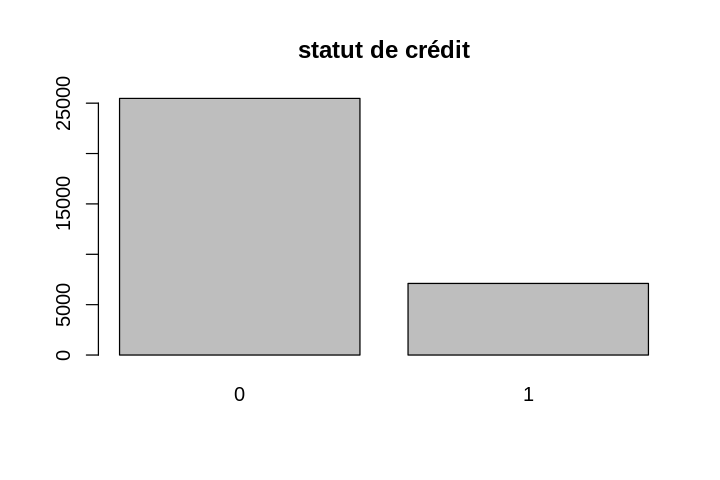

In [ ]:
# Transformation de la variable cible en variable catégorielle

df$loan_status <- as.factor(df$loan_status)

# Table de fréquence de la variable cible ('loan_status')

print(prop.table(table(df$loan_status)))

# Diagramme à barre de la variable 'loan_status'

plot(df$loan_status, main = "statut de crédit")

# Les résultats montrent qu'il y un déséquilibre de classe très importants dans les données. En effet, seulement environ 22% de clients sont en défaut de paiement contre un peu plus de 78% de bons clients.
#
# Le déséquilibre de classe est souvent observé dans les données de crédit. la majorité des demandeurs de crédit sont incités à ne pas être en défaut de paiement car plus ils remboursent le crédit dans les délais, plus leurs côtes de crédit augmentent et donc ils peuvent à nouveau emprunter pour effectuer d'autres investissements.
#
# Si le déséquilibre observé ici est tout à fait normal, il n'en demeure moins que cela représente un grand défi de classification pour les algorithmes de Machine Learning.
#
# Dans la partie préparation des données pour la modélisation, il va falloir résoudre ce problème.

Warning message:
“Removed 895 rows containing missing values or values outside the scale range
(`geom_point()`).”


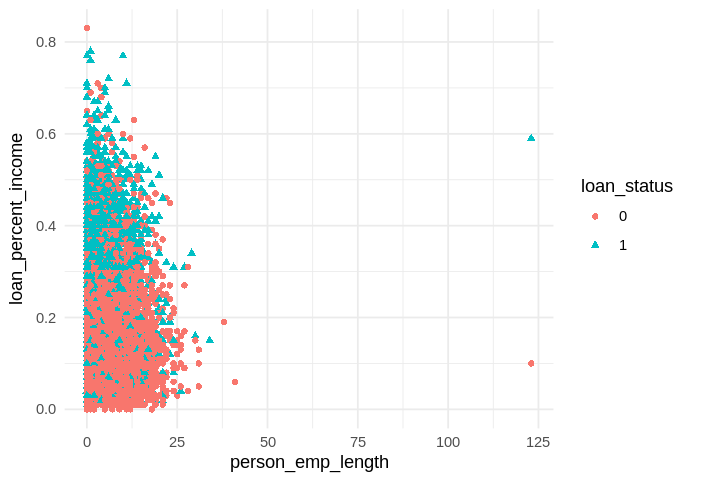

In [ ]:
# Nuage de point entre la variable cible et durée d'activité professionnelle

ggplot(df, aes(x=person_emp_length, y=loan_percent_income)) +
    geom_point(aes(color = loan_status, shape = loan_status))

<ggplot2::labels> List of 2
 $ x: chr ""
 $ y: chr "loan_percent_income"

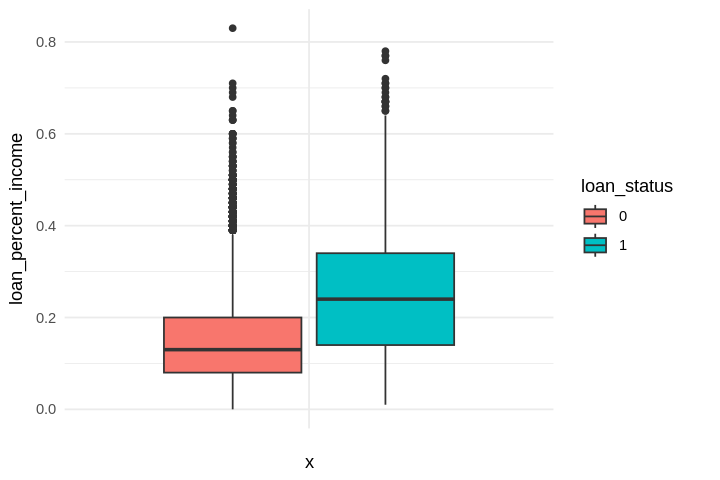

In [ ]:
# leon_percent_income vs loan_status

ggplot(df, aes(x ="", y=loan_percent_income, fill = loan_status)) +
  geom_boxplot()
  labs(x = "", y = "loan_percent_income")


# Selon ce graphique le ratio moyen dette/revenu est plus élevé chez les clients en défaut de paiement que chez les bon clients. En effet lorsque le ratio dette/revenu est très élevé, cela veut dire tout simplement que le crédit est trop élevé par rapport aux revenus de la personne. Et lorsqu'une personne a un crédit trop élevé par rapport à ses revenus, le risque qu'elle soit en défaut de paiement est logiquement et naturellement important.

In [ ]:
# Fonction de construction d'un graphique montrant la relation entre une variable indépendante et la variable cible

show_relation <- function(data, feature, title_y){
ggplot(data, aes(x ="", y=feature, fill = loan_status)) +
  geom_boxplot() +
  labs(x = "", y = title_y)

}

# Les personnes qui ont été en défaut de paiement ont en moyenne un montant de crédit plus élevé que les autres comme le montre le graphique ci-dessous.

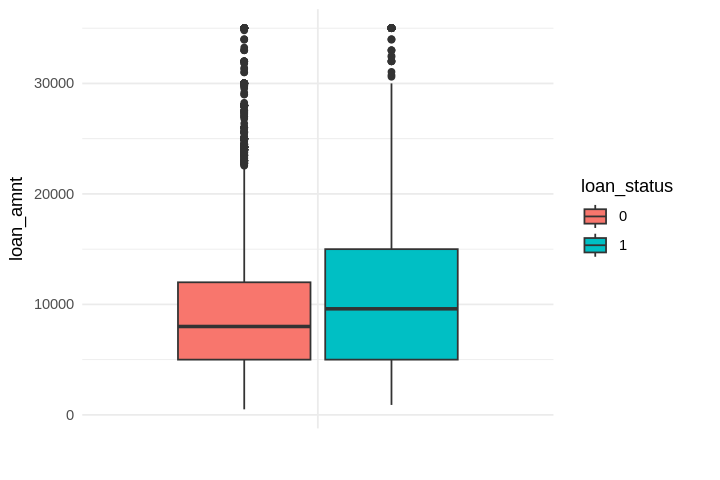

In [ ]:
# loan_amnt vs loan_status

show_relation(df, df$loan_amnt, "loan_amnt")

# Construire l'histogramme de la variable indiquant le montant du crédit

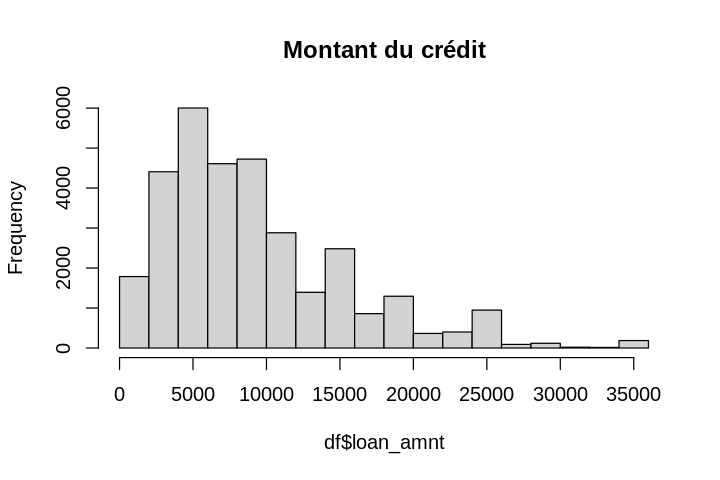

In [ ]:
# Histogramme du montant du crédit

hist(df$loan_amnt, main = "Montant du crédit")

# D'après le graphique ci-dessus, la distribution de la variable indiquant le montant du crédit est asymétrique positive (étalée vers la droite donc ne suit probablement pas une loi normale.

# Plusieurs algorithme de Machine Learning sont conçus pour fonctionner avec des données gaussiennes. Donc pour ne pas avoir des résultats biaisés, il est indispensable de vérifier l'asymétrie de chaque variable quanitative et d'éffectuer si bessoin une transformation de variable avant la phase de modélisation.

#Il est aussi intéréssant de visualiser la distribution de la variable indiquant le montant du crédit chez les personnes en défaut de paiement et chez les autres afin de pouvoir éffectuer une comparaison.

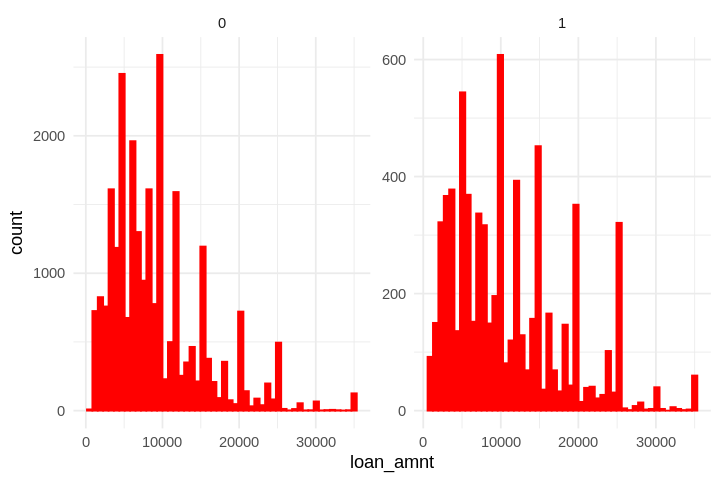

In [ ]:
# Histogramme de 'loan_amnt' discrétiser par 'loan_status'

ggplot(df, aes(x=loan_amnt)) +
  geom_histogram(color="red", fill="red", bins=50) +
  facet_wrap(~ loan_status, scales="free", ncol=2)


# Analyser à présent la variable indiquant le revenu annuel ainsi que sa relation avec la variable cible

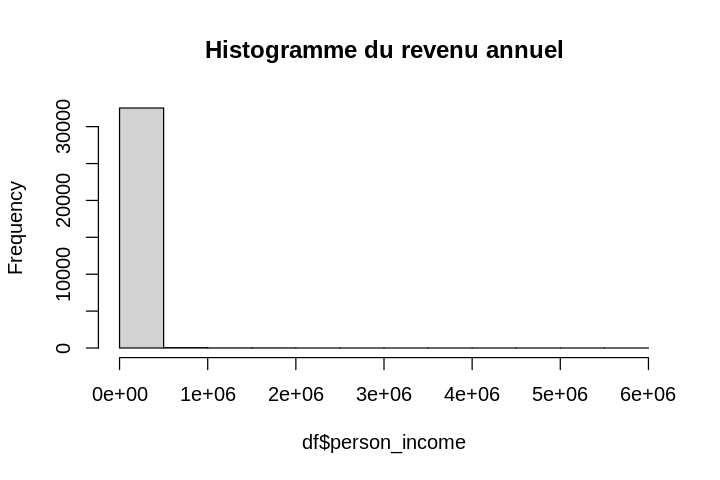

In [ ]:
# Histogramme des revenues annuels

hist(df$person_income, main = "Histogramme du revenu annuel")

# L'histogramme des revenus annuels à une seule grande barre ce qui montre qu'il y a une certaine annormale au niveau des valeurs de cette variable. En effet le résumé statisrique de la variable person_income ainsi que son histogramme révélent la présence de valeurs aberrantes (outilers) au niveau de cette variable. Nous pouvons aussi voir ces outilers en traçant un nuage de points.

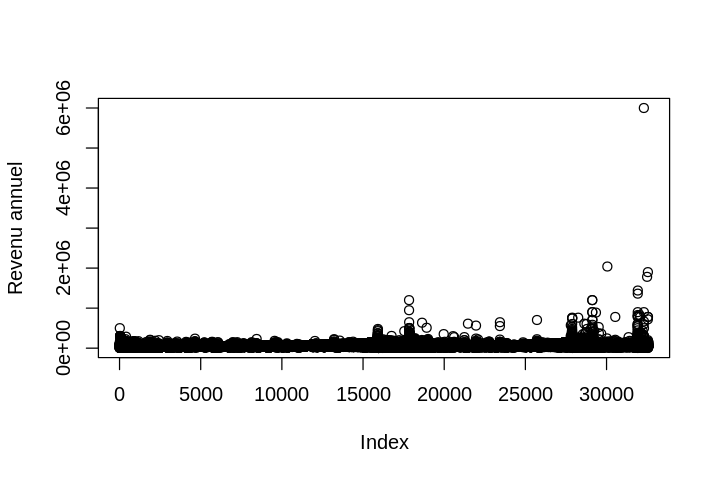

In [ ]:
# Nuage de points

plot(df$person_income, ylab="Revenu annuel")

# Le nuage de points ci-dessus confirme bel et bien la présence de valeurs aberrantes au niveau de la variable indiquant le revenu annuel. Il y a un salaire énorme de 6 millions de dollars alors tous les autres salaires annuels ne dépasse pas environ 2 millions de dollars.

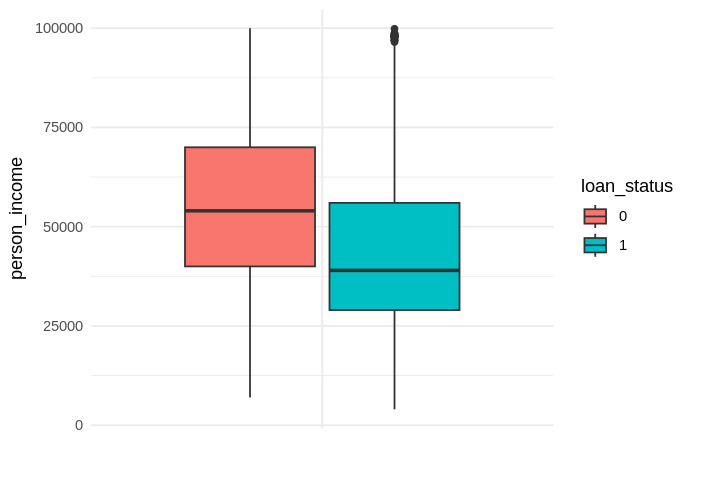

In [ ]:
# person_income vs loan_status

show_relation(subset(df, df$person_income < 100000), subset(df, df$person_income < 100000)$person_income, "person_income")

# Les personnes qui ont été en défaut de paiement ont en moyenne un revenu annuel inférieur à celui des bons clients. cette information renforce notre connaissance acquise précédemment quant au profile des personnes en défaut de paiement.

# Est ce que le taux d'intêrét influence sur le fait que le remboursement du crédit ou non ?

# Avant de tracer un graphique montrant la relation entre le taux d'intérêt  et la variable cible, visualisons d'abord l'histogramme de la variable indiquant le taux d'intérêt.

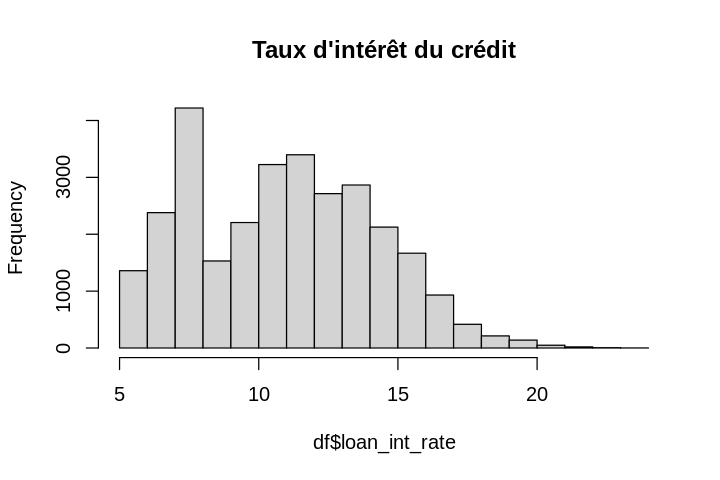

In [ ]:
# Histogramme du taux d'intérêt

hist(df$loan_int_rate, main = "Taux d'intérêt du crédit")

# Tous les crédits ont un taux d'intérêt supérieur à 5% et trés peu de crédits ont un taux d'intérêt supérieur à 20%.

Warning message:
“Removed 3116 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


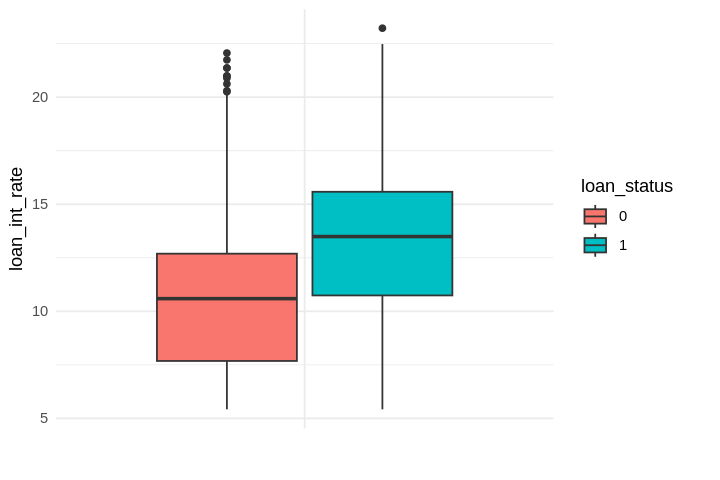

In [ ]:
# loan_int_rate vs loan_status

show_relation(df, df$loan_int_rate, "loan_int_rate")

# Les personnes en défaut de paiement ont en moyenne un taux d'intérêt plus élévé que les personnes qui ne sont pas en défaut de paiement. Ce résultat vient confirmer les résultats précédentes sur le comportement des personnes en défaut de paiement. En effet, nous avons vu que ces personnes empruntent beaucoup plus de grosses sommes que les autres donc des crédits à forts taux d'intérêts.

# Le temps pendant lequel une personne est réstée sans activité professionnelle peut probablement conditionner le remboursement ou non de son crédit.
# Construisons un histogramme de la variable person_emp_length

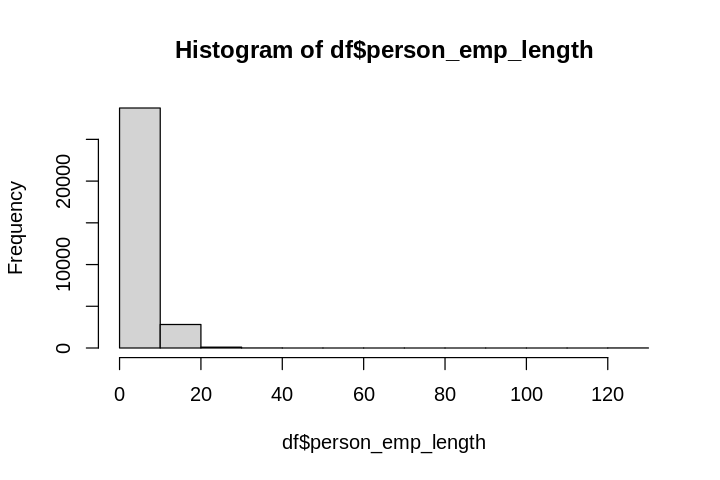

In [ ]:
# Histogramme de la variable person_emp_length

hist(df$person_emp_length)

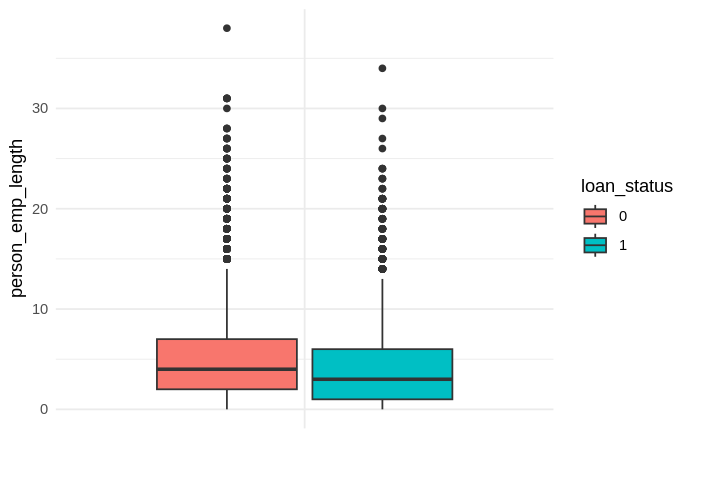

In [ ]:
# person_emp_length vs loan_status

show_relation(subset(df, df$person_emp_length < 40), subset(df,df$person_emp_length < 40)$person_emp_length,
                                                             'person_emp_length')

# Il apparait que les personne en défaut de paiement ont en moyenne une durée d'activité professionnelle inférieur à celle des autres.

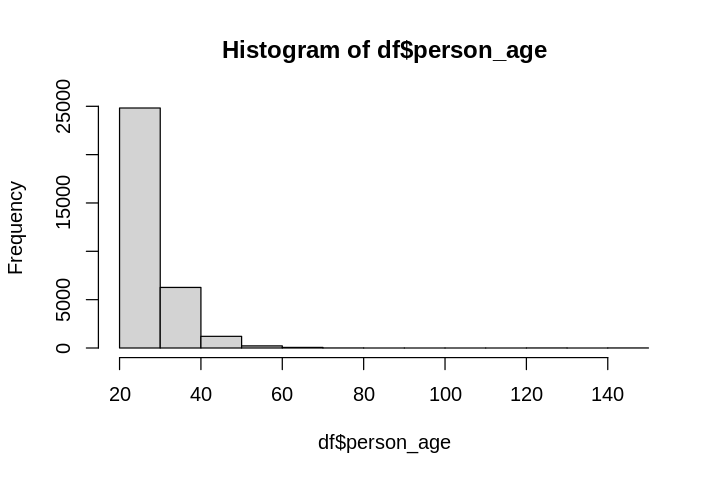

In [ ]:
# Histogramme de la variable indiquant l'âge

hist(df$person_age)

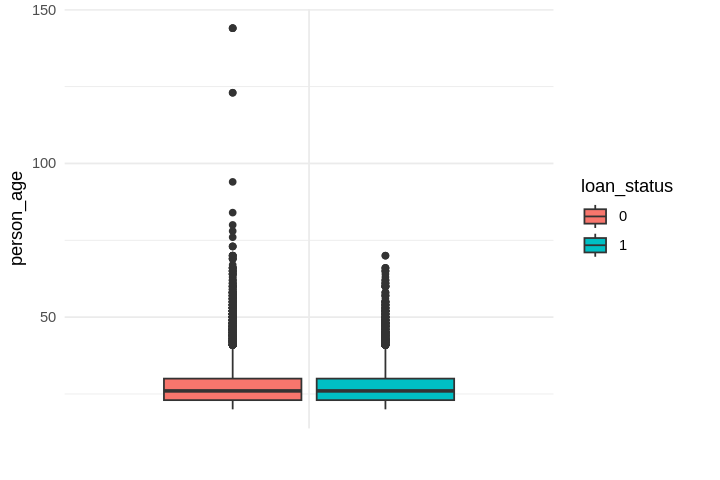

In [ ]:
# person_age vs loan_status

show_relation(df, df$person_age, 'person_age')

# Il semble que l'âge n'a aucune influence sur le remboursement ou non d'un crédit

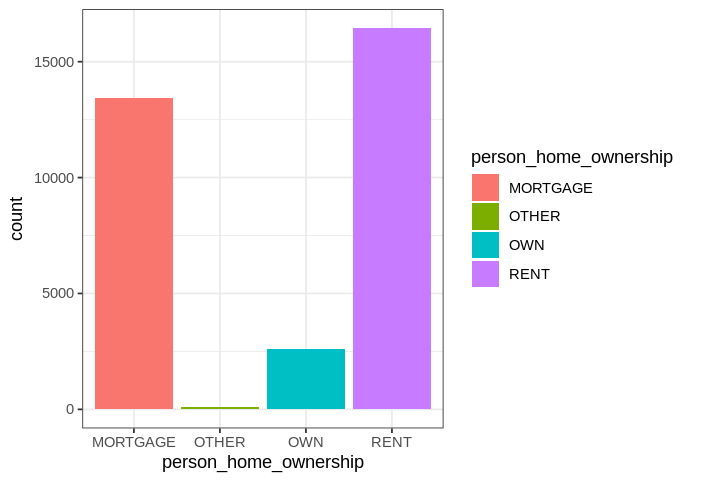

In [ ]:
# variable 'person_home_ownership'

df %>%
ggplot(aes(x=person_home_ownership, fill = person_home_ownership)) +
  geom_bar() +
  theme_bw()

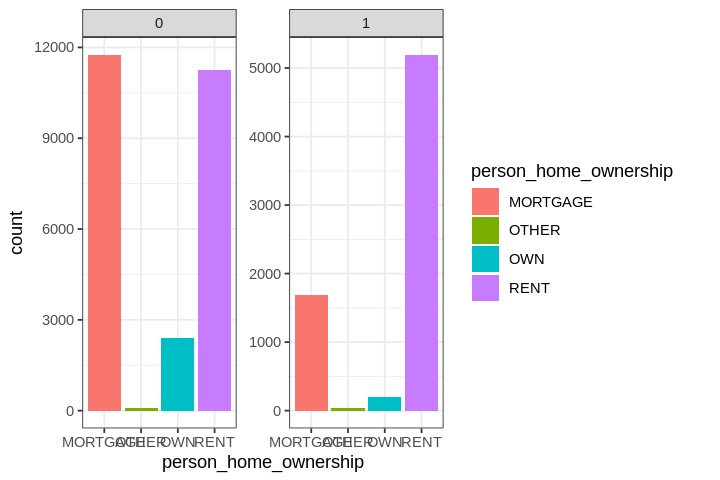

In [ ]:
# person_home_ownership

df %>%
ggplot(aes(x=person_home_ownership, fill = person_home_ownership)) +
  geom_bar() +
  theme_bw() +
    facet_wrap(~ loan_status, scales = "free", ncol = 2)

# Pour finir cette analyse exploratoire analysons les motifs pour lesquels les personnes empruntent de l'argent.

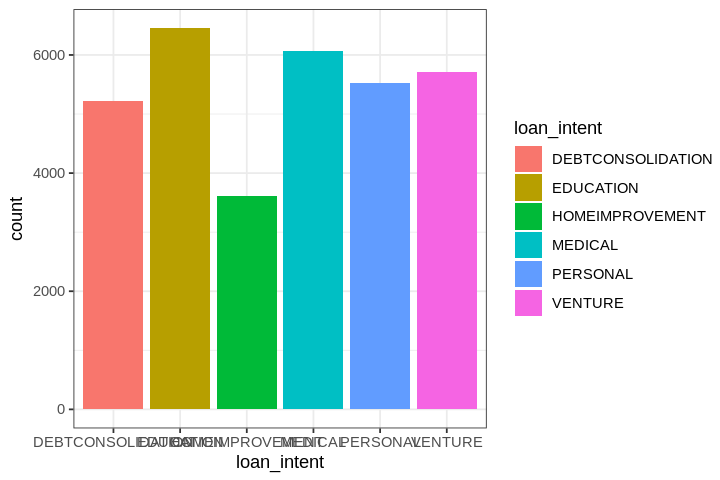

In [ ]:
# Motif de l'emprunt

df %>%
ggplot(aes(x=loan_intent, fill = loan_intent)) +
  geom_bar() +
  theme_bw()

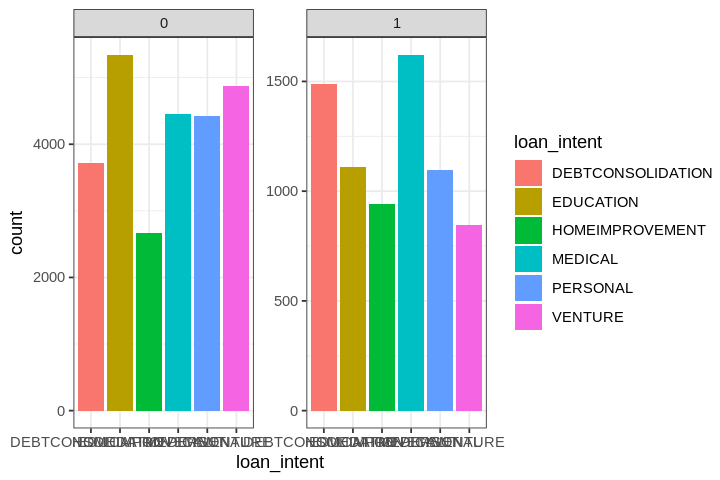

In [ ]:
# Motif de l'emprunt discrétisé selon la variable cible

df %>%
ggplot(aes(x=loan_intent, fill = loan_intent)) +
  geom_bar() +
  theme_bw() +
    facet_wrap(~ loan_status, scales = "free", ncol = 2)

# <font color=green> **Néttoyage des données**

In [ ]:
# Création d'une copie de la dataframe df

df_clean <- df

In [ ]:
# Nombre de lignes initial dans df_clean

nrow(df_clean)

[1] 32581

# <font color=red> **Outilers**

Lors de l'analyse exploratoire des données, nous avons remarqué la présence de valeurs abérrantes. Ces valeurs abérrantes peuvent affecter la qualité d'un modèle de machine Learning. Nous allons donc traiter. Avant de traiter les valeurs abérrantes, il faut d'abord les détécter.

Il existe plusieurs méthode de détection des outilers. Selon la méthode de la gammme interquartile (IQR), une valeur est abérrante si :

valeur < Q1 -1.5 * iqr

ou

valeur > Q3 + 1.5 * IQR

avec

IQR = Q3 - Q1

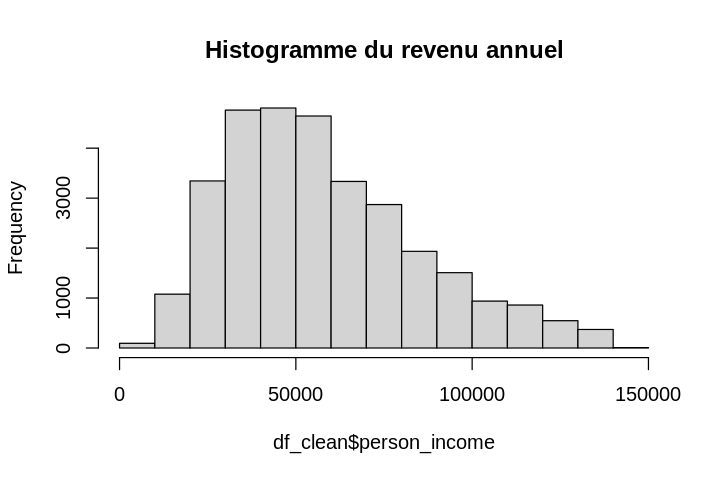

In [ ]:
# Identification des valeurs abérrantes du niveau de la variable 'person_income'

val1 = quantile(df_clean$person_income, 0.25) - 1.5 * IQR(df_clean$person_income)

vall2 = quantile(df_clean$person_income, 0.75) + 1.5 * IQR(df_clean$person_income)

index_outiler_income <- which(df_clean$person_income < val1 | df_clean$person_income > vall2)

# Supprimer des valeurs abérrantes au niveau de la variable 'person_income'

df_clean <- df_clean[-index_outiler_income, ]

# Vérification : Histogramme des revenus annuels

hist(df_clean$person_income, main = "Histogramme du revenu annuel")

# Après suppréssion des valeurs abérrantes, l'histogramme des revenus annuels a un meilleur aspect et est beaucoup plus informatif que celui construit précédement avec les données originalles.

# Une autre maniére de supprimer les valeurs abérrantes au niveau des données est de faire une simple filtration sur la base des informations recueilles lors de l'analyse exploratoire et du bon sens.
#
# Il est vrai que dans certaines banque sous certaines condition puisse accorder un crédit à une personne très âgée mais ce n'est pas ce qui ce fait en régle générale.

In [ ]:
# Suppréssion des valeurs abérrantes au niveau de la variable 'person_age'

df_clean <- subset(df_clean, df_clean$person_age < 100)

In [ ]:
# Nombre de lignes finale dans df_clean

nrow(df_clean)

[1] 31095

# <font color=red> **Valeurs manquantes**

# Il existe deux principales techniques pour traiter les valeurs manquantes :

**- Suppression** des lignes contenants des valeurs manquantes;

**- Remplacement** des valeurs manquantes en faissant des imputations par la moyenne, la médiane ...etc de la variable contenant ces valeurs manquantes.

Il existe également d'autre méthode d'autres méthodes d'imputation plus ou moins sophistiquées comme la méthode des k plus proches voisins (KNN)

Dans la pratique, il est conseillé de choisir une méthode puis de construire et d'évaluer le modèle. Puis de changer la méthode d'imputation et reconstruit le modèle ainsi de suite afin de finalement choisir une méthode qui donne les meilleurs résultats.

# **Commençons par une imputation par la médiane :**

In [ ]:
# Variable person_emp_length

index_NA_person_emp_length <- which(is.na(df_clean$person_emp_length))

df_clean$person_emp_length[index_NA_person_emp_length] <- median(df_clean$person_emp_length, na.rm=TRUE)

# Variable leon_int_rate

index_NA_rate <- which(is.na(df_clean$loan_int_rate))

df_clean$loan_int_rate[index_NA_rate] <- median(df_clean$loan_int_rate, na.rm=TRUE)



In [ ]:
# Verification 'person_emp_length

print(summary(df_clean$person_emp_length))

# Verification (loan_int_rate)

print(summary(df_clean$loan_int_rate))

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000   2.000   4.000   4.688   7.000 123.000 
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   5.42    8.49   10.99   11.00   13.11   23.22 


# <font color=green> **Préparation des données pour la phase de modélisation**

# <font color=red> **Normalisation des variables numériques**

In [ ]:
# Création d'une copie de df_clean

df_clean2 <- df_clean

In [ ]:
# Création d'une fonction de normation

#normalize <- function(x) {
#  return ((x - min(x)) / (max(x) - min(x))) }

In [ ]:
# Création d'une fonction de normation

normalize <- function(x) {
  # ne traiter que les vecteurs numériques
  if (!is.numeric(x)) return(x)

  # calcule l’étendue des valeurs de x en ignorant les NA pour la normalisation
  rng <- max(x, na.rm = TRUE) - min(x, na.rm = TRUE)

  # Si toutes les valeurs sont identiques → retourne des zéros
  if (rng == 0) return(rep(0, length(x)))
  (x - min(x, na.rm = TRUE)) / rng
}

# Met à jour toutes les colonnes du data frame correctement
df_clean2[] <- lapply(df_clean2, normalize)


In [ ]:
# Normalisation des données
# C'est de repartir les valeurs entre 0 et 1 tout en gardant les distributions originales

for (col in colnames(df_clean2)) {
  if (class(df_clean2[, col]) != 'factor') {
    df_clean2[, col] <- normalize(df_clean2[, col])
  }
}

In [ ]:
# Vérification de la normalisation

head(df_clean2)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<fct>,<dbl>,<chr>,<dbl>
1,0.02702703,0.40439987,RENT,1.000000000,PERSONAL,D,1.00000000,0.59550562,1,0.7073171,Y,0.03571429
2,0.01351351,0.04117526,OWN,0.040650407,EDUCATION,B,0.01449275,0.32134831,0,0.1097561,N,0.00000000
3,0.06756757,0.04117526,MORTGAGE,0.008130081,MEDICAL,C,0.14492754,0.41853933,1,0.6829268,N,0.03571429
4,0.04054054,0.45219258,RENT,0.032520325,MEDICAL,C,1.00000000,0.55112360,1,0.6341463,N,0.00000000
5,0.05405405,0.37057734,RENT,0.065040650,MEDICAL,C,1.00000000,0.49719101,1,0.6585366,Y,0.07142857
6,0.01351351,0.04338108,OWN,0.016260163,VENTURE,A,0.05797101,0.09662921,1,0.2926829,N,0.00000000


# <font color=red> **Données d'entrainement et de test**

# Commençons par diviser les données en un ensemble pour entrainer les algorithme et un ensemble de test pour évaluer la capacité du modèle à généraliser sur de nouvelles données (performance du modèle construit).

In [ ]:
# Données d'entrainemet (80%) et de test (20%) (Division aléatoire avec la fonction sample)

seed = 131

set.seed(seed)

index_train <- sample(1:nrow(df_clean2), 0.8 * nrow(df_clean2) )

train_set  <- df_clean2[index_train, ]

test_set <- df_clean2[-index_train, ]

In [ ]:
# Nombre de lignes dans train_set et test_set

print(nrow(train_set))

print(nrow(test_set))

[1] 24876
[1] 6219


In [ ]:
# Table de fréquence de la variable cible dans l'ensemble d'entrainement

prop.table(table(train_set$loan_status))


        0         1 
0.7779788 0.2220212 

In [ ]:
# Table de fréquence de la variable cible dans l'ensemble de test

prop.table(table(test_set$loan_status))



        0         1 
0.7684515 0.2315485 

# <font color=red> **Résolution du problème de déséquilibre de classe**

# Il existe plusieurs téchniques pour résoudre le problème de déséquilibre de classe dans les données. Le rééchantillonnage des données est l'une des téchniques les plus utilisées. Les méthodes de rééchantillonnage souvent utilisées sont :

#

#**- de sous-échantillonnement de la classe majoritaire (Randam Under Sampling ou RUS) :** cette méthode consiste à tirer au hasard des observations de cas de non-défaut pour correspondre au nombre d'observations de cas de défaut de paiement;
#**- Sur-échantillonnement de la classe minoritaire (Random Over Sampling ou ROS) :** cette méthode consiste à éffectuer des tirages aléatoires d'observations de cas de défaut et dupliquer ces observations afin de correspondre au nombre de cas de non-défaut.

#

# Ces deux méthodes conduissent à un équilibre parfait des cas de défaut et non-défaut de paiement mais présentent quand même des inconvénients. Avec le sous-échantillonnage, vous supprimez beaucoup d'information. Dans la plupart des cas, jetter des données n'est pas souhaitable en apprentissage automatique. Avec le sur-échantillonnage, vous créer beaucoup de doublons d'informations ce qui peut causser des biais importants au niveau de l'entrainement des l'algorithmes.

#

#**- Téchnique de suréchantillonnage des minorités synthétiques (Synthetic Minority Technique ou SMOTE en anglais)** : c'est une téchnique sophistiqué qui ne se contente pas de juste dupliquer des cas de défaut mais utilise les caractéristiques des plus proches voisins des cas de défaut de paiement pour créer de nouveaux cas de défaut synthétiques. Cette méthode bien qu'utilisant des algorithmes hyper-sophistiqués présente le risque que les voisins les plus proches des cas de défaut ne soient pas en réalité des cas de défaut ce qui peut entrainer des erreurs de modélisation.  

# <font color=red> NB : Les méthodes de rééchantillonnage des données pour résoudre le problème de déséquilibre de classe doivent être appliquées uniquement aux données d'entrainement et NON aux données de test.

In [ ]:
# Nombre d'observations de la classe majoritaire (non-défauts)

nrow(subset(train_set, train_set$loan_status == 0))

[1] 19353

In [ ]:
# Nombre d'observation de la classe minoritaire (défaut)

nrow(subset(train_set, train_set$loan_status == 1))

[1] 5523

In [ ]:
N <- (19353 + 5523)/2
N

[1] 12438

#<font color=red>**Sur-échantillonage de la classe minoritaire (Oversampling)**

In [ ]:
# Sur-échantillonnage de la classe minoritaire

train_oversampled <- ovun.sample(formula = loan_status ~ ., data = train_set, metho = 'over', seed = seed)

# Affichage du résultat

print(class(train_oversampled))

print(summary(train_oversampled))

[1] "ovun.sample"

Call: 
ovun.sample(formula = loan_status ~ ., data = train_set, method = "over", 
    seed = seed)

Summary of data balanced by oversampling 

   person_age      person_income    person_home_ownership person_emp_length
 Min.   :0.00000   Min.   :0.0000   Length:38699          Min.   :0.00000  
 1st Qu.:0.04054   1st Qu.:0.2179   Class :character      1st Qu.:0.01626  
 Median :0.08108   Median :0.3335   Mode  :character      Median :0.03252  
 Mean   :0.10223   Mean   :0.3679                         Mean   :0.03649  
 3rd Qu.:0.13514   3rd Qu.:0.4853                         3rd Qu.:0.04878  
 Max.   :1.00000   Max.   :1.0000                         Max.   :1.00000  
 loan_intent         loan_grade          loan_amnt      loan_int_rate   
 Length:38699       Length:38699       Min.   :0.0000   Min.   :0.0000  
 Class :character   Class :character   1st Qu.:0.1304   1st Qu.:0.2360  
 Mode  :character   Mode  :character   Median :0.2174   Median :0.3213  
              

In [ ]:
# Dataframe obtenue par la méthode de sur-échantillonnage de la classe minoritaire

train_oversampled_df <- train_oversampled$data

head(train_oversampled_df)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<fct>,<dbl>,<chr>,<dbl>
1,0.06756757,0.6691274,MORTGAGE,0.073170732,EDUCATION,A,0.50724638,0.11741573,0,0.21951220,N,0.07142857
2,0.08108108,0.4411635,RENT,0.065040650,DEBTCONSOLIDATION,B,0.20289855,0.24775281,0,0.13414634,N,0.03571429
3,0.10810811,0.5955707,MORTGAGE,0.000000000,EDUCATION,E,0.68115942,0.76460674,0,0.32926829,N,0.17857143
4,0.02702703,0.1029381,RENT,0.032520325,DEBTCONSOLIDATION,C,0.05507246,0.46011236,0,0.14634146,Y,0.03571429
5,0.06756757,0.1647010,MORTGAGE,0.008130081,HOMEIMPROVEMENT,A,0.20289855,0.19550562,0,0.32926829,N,0.03571429
6,0.05405405,0.9117379,MORTGAGE,0.032520325,EDUCATION,A,0.33333333,0.03426966,0,0.09756098,N,0.00000000


In [ ]:
# La proportion

prop.table(table(train_oversampled_df$loan_status))


        0         1 
0.5000904 0.4999096 

#<font color=red>**Sous-échantillonage de la classe majoritaire (Undersampling)**

In [ ]:
# Méthode de sous-échantillonnage de la classe majoritaire (RUS)

train_undersampled <- ovun.sample(formula = loan_status ~ ., data = train_set, method = 'under', seed = seed)

# Affichage

print(class(train_undersampled))

print(summary(train_undersampled))

[1] "ovun.sample"

Call: 
ovun.sample(formula = loan_status ~ ., data = train_set, method = "under", 
    seed = seed)

Summary of data balanced by undersampling 

   person_age      person_income    person_home_ownership person_emp_length
 Min.   :0.00000   Min.   :0.0000   Length:11009          Min.   :0.00000  
 1st Qu.:0.04054   1st Qu.:0.2154   Class :character      1st Qu.:0.01626  
 Median :0.08108   Median :0.3309   Mode  :character      Median :0.03252  
 Mean   :0.10231   Mean   :0.3667                         Mean   :0.03631  
 3rd Qu.:0.13514   3rd Qu.:0.4840                         3rd Qu.:0.04878  
 Max.   :0.78378   Max.   :1.0000                         Max.   :1.00000  
 loan_intent         loan_grade          loan_amnt      loan_int_rate   
 Length:11009       Length:11009       Min.   :0.0000   Min.   :0.0000  
 Class :character   Class :character   1st Qu.:0.1304   1st Qu.:0.2360  
 Mode  :character   Mode  :character   Median :0.2174   Median :0.3213  
            

In [ ]:
# Dataframe obtenue par la méthode de sous-échantillonnage de la classe majoritaire

train_undersampled_df <- train_undersampled$data

head(train_undersampled_df)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<fct>,<dbl>,<chr>,<dbl>
1,0.05405405,0.3823417,MORTGAGE,0.02439024,EDUCATION,A,0.4202899,0.17247191,0,0.3170732,N,0.00000000
2,0.04054054,0.3676362,RENT,0.05691057,DEBTCONSOLIDATION,B,0.4362319,0.35337079,0,0.3414634,N,0.07142857
3,0.06756757,0.8161525,MORTGAGE,0.07317073,VENTURE,C,0.5362319,0.45337079,0,0.1951220,Y,0.07142857
4,0.10810811,0.3749890,OWN,0.00000000,DEBTCONSOLIDATION,D,0.1797101,0.63764045,0,0.1341463,Y,0.17857143
5,0.06756757,0.3749890,RENT,0.07317073,EDUCATION,B,0.2463768,0.31292135,0,0.1829268,N,0.07142857
6,0.05405405,0.2646981,RENT,0.00000000,DEBTCONSOLIDATION,A,0.2985507,0.08426966,0,0.3170732,N,0.07142857


In [ ]:
# La proportion

prop.table(table(train_undersampled_df$loan_status))


        0         1 
0.4983196 0.5016804 

# Il est possible de créer un ensemble de données équilibré en combinant le sur-échantillonnage de la classe minoritaire et le sous-échantillonnage de la classe majoritaire :

In [ ]:
# Combinaison des téchniques ROS et RUS

train_ros_rus <- ovun.sample(formula = loan_status ~ ., data = train_set, method = 'both', N = 1200, seed = seed)

In [100]:
# Dataframe obtenue par la combinaison des téchniques ROS et RUS

train_ros_rus_df <- train_ros_rus$data

head(train_ros_rus_df)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<fct>,<dbl>,<chr>,<dbl>
1,0.20270270,0.5551307,MORTGAGE,0.04065041,PERSONAL,D,0.26376812,0.5162921,0,0.13414634,Y,0.10714286
2,0.13513514,0.2646981,MORTGAGE,0.07317073,DEBTCONSOLIDATION,B,0.07246377,0.3533708,0,0.07317073,N,0.17857143
3,0.10810811,0.6323343,MORTGAGE,0.09756098,HOMEIMPROVEMENT,C,0.33333333,0.4775281,0,0.14634146,N,0.14285714
4,0.09459459,0.5220435,RENT,0.03252033,VENTURE,C,0.01449275,0.4533708,0,0.00000000,Y,0.25000000
5,0.09459459,0.3970177,RENT,0.06504065,DEBTCONSOLIDATION,C,0.36231884,0.4775281,0,0.25609756,Y,0.17857143
6,0.04054054,0.1647010,RENT,0.03252033,PERSONAL,A,0.12463768,0.3129213,0,0.20731707,N,0.07142857


In [ ]:
# La proportion

prop.table(table(train_ros_rus_df$loan_status))


        0         1 
0.5008333 0.4991667 

# <font color=green> **La modélisation**

# <font color=blue> **Choix de la métrique d'évaluation de performance du modèle : Accuracy | Sensitivity | Specificity ?**

# <font color=red> **Modèle de Régression logistique**

In [ ]:
# Création d'une fonction de construction d'un modèle de régression logistique

log_modeling <- function(train){
  model <-glm(loan_status ~., family = 'binomial', data = train)
  return (model)
}

# <font color=blue> **Construction et évaluation d'un modèle de régression logistique**

In [ ]:
# Construction d'un modèle de régression logistique avec tous les prédicteurs disponibles

log_model <- log_modeling(train_set)

# Résumé du modèle

summary(log_model)


Call:
glm(formula = loan_status ~ ., family = "binomial", data = train)

Coefficients:
                           Estimate Std. Error z value Pr(>|z|)    
(Intercept)                -3.45231    0.12742 -27.093  < 2e-16 ***
person_age                 -0.61202    0.49087  -1.247 0.212468    
person_income              -0.77061    0.24138  -3.193 0.001410 ** 
person_home_ownershipOTHER  0.61742    0.31424   1.965 0.049436 *  
person_home_ownershipOWN   -1.64524    0.11192 -14.700  < 2e-16 ***
person_home_ownershipRENT   0.85323    0.04614  18.490  < 2e-16 ***
person_emp_length          -1.78576    0.66498  -2.685 0.007244 ** 
loan_intentEDUCATION       -0.81461    0.06474 -12.582  < 2e-16 ***
loan_intentHOMEIMPROVEMENT  0.14321    0.07301   1.962 0.049806 *  
loan_intentMEDICAL         -0.14525    0.06124  -2.372 0.017708 *  
loan_intentPERSONAL        -0.59841    0.06634  -9.020  < 2e-16 ***
loan_intentVENTURE         -1.04814    0.07031 -14.908  < 2e-16 ***
loan_gradeB                 

# Certains prédicteurs sont statistiquement significatifs tandis que d'autres ne le sont pas.

In [ ]:
# Prédictions sur les données de test

preds_log <- predict(log_model, newdata = test_set, type = 'response')

head(preds_log)

9         11         12         13         14         15 
0.15294352 0.13089120 0.56474833 0.05688180 0.49922268 0.02800178

# preds_log donne la probabilité de défaut de paiement de chaque client de l'ensemble des données de test. Pour identifier les mauvais emprunteurs des bons, il faut définir une valeur seuil. Par exemple on peut dire que si la probabilité prédite du client est inférieur à 0.5 alors il n'est pas en défaut de paiement et dans le cas contraire, c'est à dire pour une probabilité supérieur à 0.5, le client est en défaut de paiement.

#
# Une autre façon de définir le seuil est de considérer la moyenne de la variable cible c'est à dire la proportion de la classe 1 (voir résumé statistique)

In [ ]:
# Définir d'un seuil

seuil <- 0.3

# Convertir des probabilités en résultats (0 ou 1) de la variable 'loan_status'

preds_status <- ifelse(preds_log > seuil, 1, 0)

# Matrice de confusion

conf_mat <- table(test_set$loan_status, preds_status)

In [ ]:
conf_mat

   preds_status
       0    1
  0 4182  597
  1  398 1042

In [ ]:
# Composante de la matrice de confusion

TP <- conf_mat[2, 2]

TN <- conf_mat[1, 1]

FP <- conf_mat[1, 2]

FN <- conf_mat[2, 1]

In [ ]:
# Score de classification

accuracy <- (TP + TN) / nrow(test_set)

accuracy

[1] 0.8400064

# La précision de clasification est égale à 86.22% pour un seuil égal à 0.5

# La précision de clasification est égale à 85.6% pour un seuil égal à 0.4

# La précision de clasification est égale à 84% pour un seuil égal à 0.3

In [ ]:
# Sensibilité du modèle

sensitivity <- TP / (TP + FN)

sensitivity

[1] 0.7236111

# Le modèle prédit correctement 56.6%  des clients qui sont en réalité en défaut de paiement pour un seuil égal à 0.5

# Le modèle prédit correctement 64.3%  des clients qui sont en réalité en défaut de paiement pour un seuil égal à 0.4

# Le modèle prédit correctement 72.4%  des clients qui sont en réalité en défaut de paiement pour un seuil égal à 0.3

In [ ]:
# Spécificité du model

specificity <- TN / (TN + FP)

specificity

[1] 0.8750785

# Le model prédit correctement 95.15% des clients qui ne sont pas en défaut de paiement pour un seuil égal à 0.5.

# Le model prédit correctement 92.03% des clients qui ne sont pas en défaut de paiement pour un seuil égal à 0.4.

# Le model prédit correctement 87.51% des clients qui ne sont pas en défaut de paiement pour un seuil égal à 0.3.

# On remarque que plus le seuil est élevé, plus le score de classification augmente, plus la sensibilité diminue et plus la spécificité du modèle augment. Dans la suite, nous analysons en profondeur les différentes métriques d'évaluation pour diférents seuil.
#
# Mais avant, créons une fonction d'évaluation de la performance d'un modèle que nous allons pouvoir réutiliser pour d'autre modèle.

In [ ]:
# Créons d'une fonction d'évaluation de modèle

model_evaluation <- function(model,  seuil){

  predictions <- predict(model, newdata = test_set, type = 'response')
  predicted_status <- ifelse(predictions > seuil, 1, 0)
  conf_mat <- table(test_set$loan_status, predicted_status)
  accuracy <- (conf_mat[2, 2] + conf_mat[1, 1]) / nrow(test_set)
  sensitivity <- conf_mat[2, 2] / (conf_mat[2, 2] + conf_mat[2, 1])
  specificity <- conf_mat[1, 1] / (conf_mat[1, 1] + conf_mat[1, 2])
  one_minus_spec <- 1 - specificity

  results <- list(conf_mat, accuracy, sensitivity, specificity, one_minus_spec)
  names(results) <- c('Matrice de confusion', 'Score de classification',
                    'Sensibilité du modèle', 'Spécificité du modèle',
                    'one_minus_spec')

  return (results)
}

In [ ]:
# Vérifions de la fonction

model_evaluation(log_model, 0.3)

$`Matrice de confusion`
   predicted_status
       0    1
  0 4182  597
  1  398 1042

$`Score de classification`
[1] 0.8400064

$`Sensibilité du modèle`
[1] 0.7236111

$`Spécificité du modèle`
[1] 0.8750785

$one_minus_spec
[1] 0.1249215


# Il est clair que le seuil (la probabilité) à partir duquel on définit si une personne sera en défaut de paiement ou pas influence la performance du modèle de classification. Alors quel seuil 'optimal' faut-il choisir ?
#
# Pour résoudre à cette question, il serait intérésant de tracer un graphique montrant les résulutats des différentes métriques pour divers seuils ce qui permettrait à la banque de prendre une décision en ce qui concerne le seuil "optimal".

In [ ]:
# Création d'une fonction d'affichage des résultats de modèles pour divers seuils

print_results <- function(model){

  # définition des seuils
  seuils <- seq(0.01, 0.99, by = 0.01)

  # Vécteurs vides pour stocker les métriques d'évaluation du modèle pour divers seuils
  acc_model <- c()
  sens_model <- c()
  spec_model <- c()
  one_minus_spec_model <- c()

  for (i in seuils){
    r <- model_evaluation(model, i)
    acc_model <- append(acc_model, r[['Score de classification']])
    sens_model <- append(sens_model, r[['Sensibilité du modèle']])
    spec_model <- append(spec_model, r[['Spécificité du modèle']])
    one_minus_spec_model <- append(one_minus_spec_model, r[['one_minus_spec']])
  }

  # Dataframe des métriques pour divers seuils
  resultats <- data.frame(cbind(seuils, acc_model, sens_model, spec_model, one_minus_spec_model))

  # Graphique montrant les métriques pour differents seuils
  plots <- ggplot() +
    geom_line(data=resultats, aes(x=seuils, y=acc_model, color='red')) +
    geom_line(data=resultats, aes(x=seuils, y=sens_model, color='green')) +
    geom_line(data=resultats, aes(x=seuils, y=spec_model, color='red')) +
    labs(x = 'seuils', y = 'score') +
    scale_color_discrete(name = 'métrics', labels = c("accuracy", "sensitivity", "specificity"))

  # Courbe ROC qui monttre la relation existante entre la spécificité et la sensibilité
  roc_curve <-ggplot() +
    geom_line(data=resultats,
          aes(x=one_minus_spec_model, y=sens_model)) +
    labs(x = '1 - specificity', y = 'sensitivity')

  # Résultats de la fonction
  all_results <- list(resultats, plots, roc_curve)
  names(all_results) <- c('métrics', 'plot', 'roc_curve')

  return (all_results)
}

In [ ]:
# Métriques de log_model pour divers seuils

# Les 5 dérniéres lignes
head(print_results(log_model)[['métrics']])

,seuils,acc_model,sens_model,spec_model,one_minus_spec_model
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,0.01,0.2849333,0.9993056,0.06967985,0.9303202
2,0.02,0.3597041,0.9902778,0.16970077,0.8302992
3,0.03,0.4257919,0.9729167,0.26093325,0.7390668
4,0.04,0.4774079,0.9541667,0.33375183,0.6662482
5,0.05,0.5243608,0.9444444,0.39778196,0.6022180
6,0.06,0.5626306,0.9291667,0.45218665,0.5478134


In [ ]:
# Les 5 dérniéres lignes
tail(print_results(log_model)[['métrics']])

,seuils,acc_model,sens_model,spec_model,one_minus_spec_model
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
94,0.94,0.7874256,0.08263889,0.9997908,0.0002092488
95,0.95,0.7840489,0.06805556,0.9997908,0.0002092488
96,0.96,0.7805113,0.05277778,0.9997908,0.0002092488
97,0.97,0.7779386,0.04166667,0.9997908,0.0002092488
98,0.98,0.7748834,0.02847222,0.9997908,0.0002092488
99,0.99,0.7718283,0.01527778,0.9997908,0.0002092488


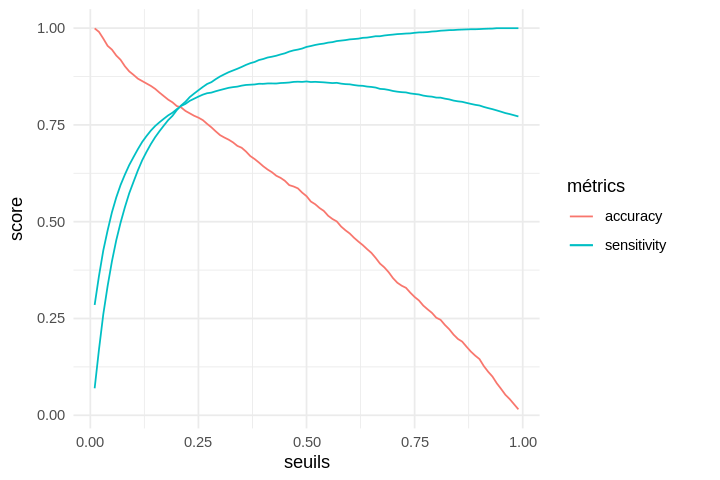

In [ ]:
# Graphique montrant les métriques de log_modèl pour divers seuils

print_results(log_model)[['plot']]

#  <font color=green> **Choix d'un seuil "optimal"**

# La nature croissante du score de classification (Accuracy) à mesure que le seuil augmente est un résultat très typique en général pour une régression logistique avec des classes déséquilibrées et en particulier pour la modélisation du risque de crédit. Donc si on considérait uniquement le score de classification , on serait tenté de choisir par exemple un seuil de 50%. Mais comme vous le saviez, le score de classification n'est pas une métrique adaptée pour évaluer un modèl de classification lorsqu'il y a un déséquilibre de classe.

#

# En ce qui concerne la sensibilité et la spécificité, nous constatons qu'a mesure que le suil augmente, la sensibilité diminue et la spécificité augmente. Ceci est aussi valable pour tous les cas de classification par un algorithme d'apprentissage automatique. C'est-à-dire que vous améliorez la sensibilité, la spécificité est diminuée et vice-versa. Par exemple, pour un seuil de 0,01, nous obtenons une sensibilité d'environ 100% (sa valeur maximale) et une spécificité d'environ 25% (sa valeur minimale). De plus, pour un seuil de 0,99, la sensibilité est d'environ 0% (sa valeur miimale) et la spécificité égale à un peu plus de 75% (sa valeur maximale).

#

# Donc, il y'a compromis à faire entre la sensibilité et la spécificité. Le choix d'un seuol "optimal" est donc d'une importance capitale non seulement parce-qu'il modifie les valeurs des métriques d'évaluation de la pérformance du modèle mais parce que ce choix implique directement des conséquences sur les décisions à prendre en ce qui concerne les nouveaux demandeurs de crédit. C'est-à-dire ce seuil permettra de décider si la banque accorde ou pas un prêt à un nouveau demandeur de crédit.

#

# Il est clair qu'aucun modèle n'est parfait et peu importante le choix du seuil, il y aura toujours des débiteurs qui seront en défaut de dépaiement. Mais un modèle sera mieux qu'une simple dévinette pour le choix des prêts que la banque devra accorder. Le modèle est une grande aide à la décision et aide la banque à décider du nombre de prêts qu'elle doit approuver si elle ne veut pas dépasser un certain pourcentage de défauts de paiment dans leur protfeuille de clients.

#

# Je sais que vous êtes tenté de dire que le meilleur seuil est celui du point d'intersection entre la courbe de sensibilité et celle de spécificité. C'est possible!
#De toute les façons, la banque doit évaluer l'impact de sa décision en ce concerne le choix d'un seuil et adopter périodiquement ce choix en fonction des nouvelles données qu'elle aura : Mise à jour du modèle

# <font color=reen> **Courbe ROC**

#En réalité, dans la pratique, les banque veulent simplement savoir quoi est globalement le meilleur modèle sans savoir à faire des hypothéses sur le seuil. La courbe ROC (RRceiver Operating Charateristic) est la méthode d'évaluation utilisé pour cela.

#

#La courbe ROC est un graphique qui montre comment les taux de vrais positifs et faux positifs varient pour un modèle lorsque le seuil est modifié.

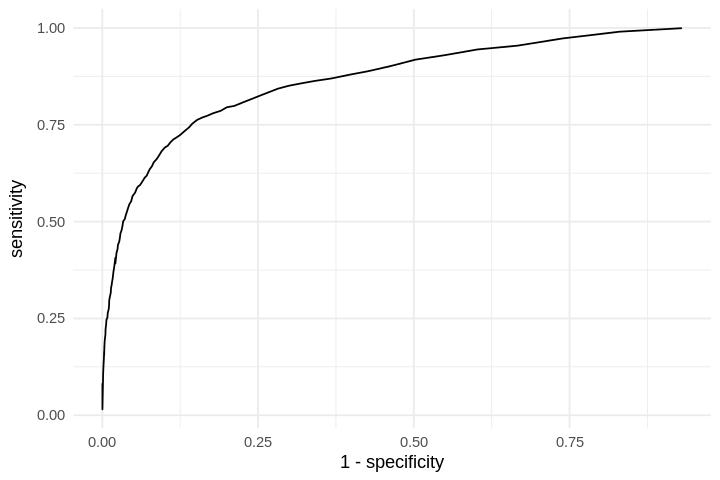

In [ ]:
# Courbe ROC de log_model

print_results(log_model)[['roc_curve']]

#La courbe ROC commence toujours dans le coin inférieur gauche où la sensibilité est égale à 0 et la spécificité est égale à 1 ce qui correspond au classement de tous les clients comme étant des cas de non-défaut de paiement. L'autre éxtrémité de la courbe (coin en haut à droite) correspond à une sensibilité égale à 1 et donc une spécificité de 0 e qui correspond au classement de tous les clients comme étant des cas de défaut de paiement.

#

#De maniére générale, la zone optimale de la courbe ROC est celle qui est la plus proche du coin supérieur gauche (du cadre du graphique) mieux c'est cette zone corréspond à des sensibilité plus élévées associées élevées.

#

#Une mesure que les banques aiment uttiliser pour comparer les courbes ROC (et donc comparer plusieurs modèles de classification) est l'AUC (Area Under the Curve). Puis cette mesure est élevée, meilleur est le modèle pour prédire une classe négative comme négative et une classe possitive comme positive. La valeur varie de 0 à 1.

In [ ]:
# AUC vs seuils de log_model

auc_model <- function(model){
  predictions <- predict(model, newdata = test_set, type = 'response')
  return (auc(roc(test_set$loan_status, predictions)))
}

In [ ]:
auc_model(log_model)

Setting levels: control = 0, case = 1

Setting direction: controls < cases



Area under the curve: 0.8705

# L'AUC est égale à 0.8705 ce qui signifie que ce modèle à une probabilité de 87.06% de distinguer correctement une classe négative d'une classe positive.

#

# L'AUC est utilisé pour comparer les modèles

# <font color=red> **Stepwise regression model**

# En l'absence d'expertise en la matiére de régression logistique par étapes (**Stepwise regression model**) peut aider à la recherche des prédicteurs les plus importants.
#
# La régression pas à pas consiste un modèle de régression étape par étape en évaluant chaque prédicteur afin d'identifier ceux qui apportent de la valeur au modèle finale. Il existe deux type d'algorithme de **Stepwise regression**;

# **backward stepwise :** cet agorithme commence par un modèle contenant tous les prédicteurs. Il verifie ensuite ce qui se passe lorsque chacun de prédicteurs est supprimé du modèle. Si la suppréssion d'un prédicteur n'a pas d'impact substantiel sur la performance du modèle alors l'algorithme supprime définitivement cette variable. Donc à chaque étape de l'éxécution de l'algorithme, le prédicteur qui impacte le moins la performance du modèle est supprimé. Cela se produit jusqu'à ce qu'il reste seulement les prédicteurs importants.
#
# **forward stepwise :** c'est la même idée de sélection des prédicteurs importants du **backwar Stepwise** mais dans le sens inverse. Ici, l'algorithme commence par un modèle ne contenant aucun prédicteur et ajouté à chaque étape un prédicteur en examant l'amélioration qu'apporte ce prédicteur quant à la performance du modèle. Les prédicteurs sont ajoutés étape  par étape jusqu'à ce qu'aucun nouveau prédicteur n'apporte une valeur substantielle du modèle.
#
# Il est possible que pour un même ensemble de données d'entrainement. Ces deux algorithme ne donnent pas le même résultat en ce qui concerne les prédicteurs importants.

In [ ]:
# Aide sur la fonction step()
#?step()

In [ ]:
# Sélection automatique des variable (forward regression)

null_model <- glm(loan_status ~ 1, data = train_set, family = 'binomial')

forward_model <- step(null_model,
                      scope =list(lower = null_model, upper = log_model),
                      direction = 'forward',
                      steps = 2000)

Start:  AIC=26343.41
loan_status ~ 1

                             Df Deviance   AIC
+ loan_grade                  6    22656 22670
+ loan_percent_income         1    22986 22990
+ loan_int_rate               1    23738 23742
+ person_income               1    24510 24514
+ person_home_ownership       3    24826 24834
+ cb_person_default_on_file   1    25594 25598
+ loan_intent                 5    25960 25972
+ loan_amnt                   1    25989 25993
+ person_emp_length           1    26170 26174
+ person_age                  1    26335 26339
+ cb_person_cred_hist_length  1    26339 26343
<none>                             26341 26343

Step:  AIC=22670.12
loan_status ~ loan_grade

                             Df Deviance   AIC
+ loan_percent_income         1    19596 19612
+ person_income               1    20574 20590
+ person_home_ownership       3    21287 21307
+ loan_intent                 5    22248 22272
+ person_emp_length           1    22500 22516
+ loan_amnt           

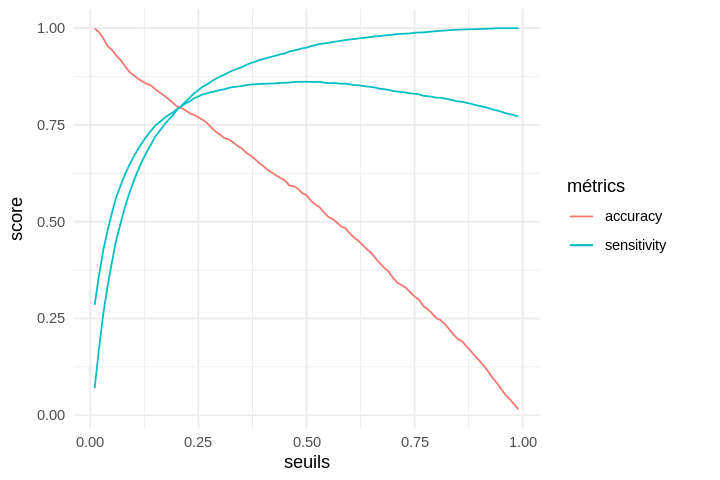

In [ ]:
# Graphique montrant les métriques de forward_model pour divers seuils

print_results(forward_model)[['plot']]


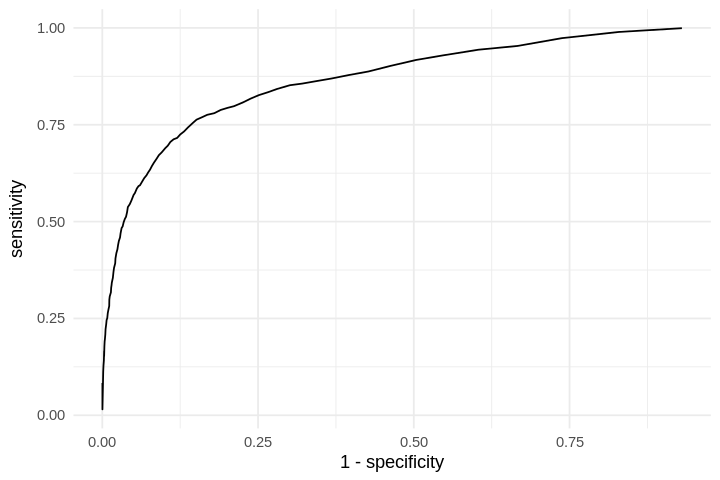

In [ ]:
# Courbe ROC de forward_model

print_results(forward_model)[['roc_curve']]

In [ ]:
# AUC de forward_model

auc_model(forward_model)

Setting levels: control = 0, case = 1

Setting direction: controls < cases



Area under the curve: 0.8705

# Construison et évaluons un modèle de régression logistique en utilisant les données d'entrainement obtenues par la méthode de sur-échantillonnage de la classe minoritaire :

In [ ]:
# Modèle avec les données d'entrainement sur-échantillonnage

log_model_ros <- log_modeling(train_oversampled_df)

summary(log_model_ros)


Call:
glm(formula = loan_status ~ ., family = "binomial", data = train)

Coefficients:
                            Estimate Std. Error z value Pr(>|z|)    
(Intercept)                -2.100069   0.083093 -25.274  < 2e-16 ***
person_age                 -0.033111   0.332695  -0.100    0.921    
person_income              -1.096342   0.150347  -7.292 3.05e-13 ***
person_home_ownershipOTHER  0.331288   0.225926   1.466    0.143    
person_home_ownershipOWN   -1.604255   0.070491 -22.758  < 2e-16 ***
person_home_ownershipRENT   0.652215   0.030687  21.254  < 2e-16 ***
person_emp_length           0.120094   0.448540   0.268    0.789    
loan_intentEDUCATION       -0.625923   0.044160 -14.174  < 2e-16 ***
loan_intentHOMEIMPROVEMENT  0.340617   0.050029   6.808 9.87e-12 ***
loan_intentMEDICAL         -0.100474   0.043179  -2.327    0.020 *  
loan_intentPERSONAL        -0.389787   0.045395  -8.587  < 2e-16 ***
loan_intentVENTURE         -1.020050   0.048057 -21.226  < 2e-16 ***
loan_gradeB    

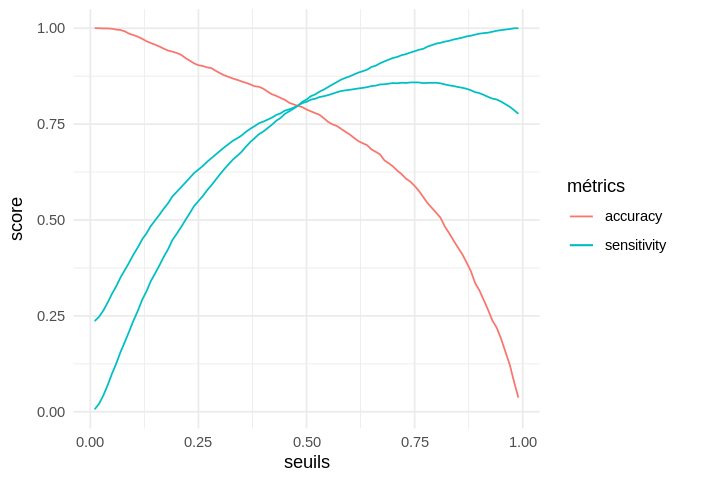

In [ ]:
# Métrique de log_model_ros pour divers seuils

print_results(log_model_ros)[['plot']]

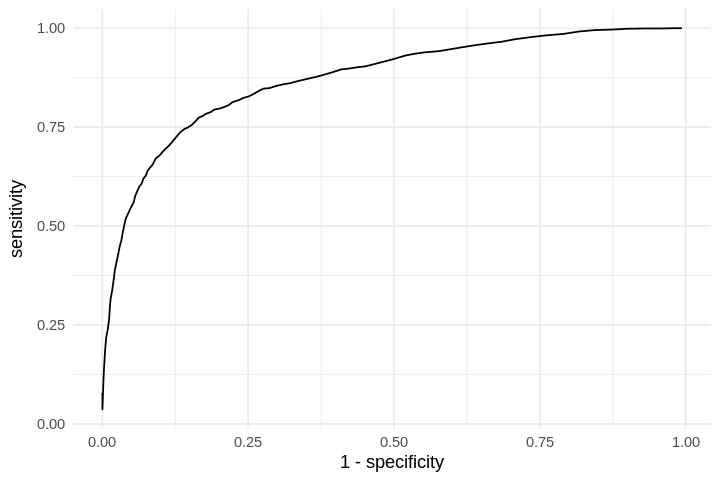

In [ ]:
# Courbe ROC de log_model_ros

print_results(log_model_ros)[['roc_curve']]

In [ ]:
# AUC de log_model_ros

auc_model(log_model_ros)


Setting levels: control = 0, case = 1

Setting direction: controls < cases



Area under the curve: 0.8729

# Construison et évaluons un modèle de régression logistique en utilisant les données d'entrainement obtenues par la méthode de sous-échantillonnage de la classe majoritaire :

In [ ]:
# Modèle avec les données d'entrainement sous-échantillonnage

log_model_rus <- log_modeling(train_undersampled_df)

summary(log_model_rus)


Call:
glm(formula = loan_status ~ ., family = "binomial", data = train)

Coefficients:
                            Estimate Std. Error z value Pr(>|z|)    
(Intercept)                 -2.19592    0.15425 -14.236  < 2e-16 ***
person_age                  -0.02179    0.63310  -0.034 0.972548    
person_income               -1.02415    0.27815  -3.682 0.000231 ***
person_home_ownershipOTHER   0.44654    0.43991   1.015 0.310067    
person_home_ownershipOWN    -1.62168    0.13146 -12.336  < 2e-16 ***
person_home_ownershipRENT    0.67790    0.05762  11.765  < 2e-16 ***
person_emp_length            0.52221    0.84298   0.619 0.535598    
loan_intentEDUCATION        -0.58248    0.08317  -7.004 2.50e-12 ***
loan_intentHOMEIMPROVEMENT   0.23918    0.09340   2.561 0.010445 *  
loan_intentMEDICAL          -0.07546    0.08094  -0.932 0.351177    
loan_intentPERSONAL         -0.45033    0.08547  -5.269 1.37e-07 ***
loan_intentVENTURE          -0.98411    0.08957 -10.987  < 2e-16 ***
loan_gradeB    

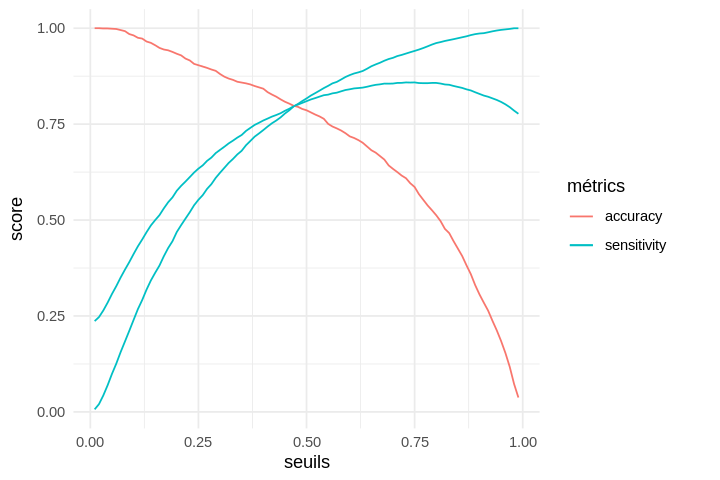

In [ ]:
# Métriques de log_model_rus pour divers euils

print_results(log_model_rus)[['plot']]

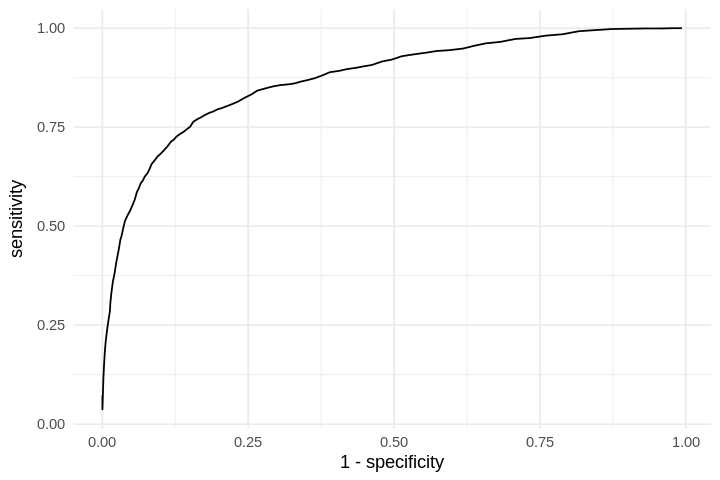

In [ ]:
# Courbe ROC de log_model_rus

print_results(log_model_rus)[['roc_curve']]

In [ ]:
# AUC de log_model_rus

auc_model(log_model_rus)

Setting levels: control = 0, case = 1

Setting direction: controls < cases



Area under the curve: 0.8727

# **Construisons et évaluons un modèle de régression logistiques en utilisant les données d'entrainemment obtenues par combinaison de la méthode de sur-échantillonnage de la classe minoritaire et de la méthode de sous-échantillonnage de la classe majoritaire :**

In [102]:
# Modèle avecc les données d'entrainement obtenues par combinaison du sur*échantillonnage et du sous-échantillonnage

log_model_ros_rus <- log_modeling(train_ros_rus_df)

summary(log_model_ros_rus)


Call:
glm(formula = loan_status ~ ., family = "binomial", data = train)

Coefficients:
                            Estimate Std. Error z value Pr(>|z|)    
(Intercept)                 -1.74179    0.50737  -3.433 0.000597 ***
person_age                  -3.75663    1.72311  -2.180 0.029246 *  
person_income               -1.84039    0.99724  -1.845 0.064968 .  
person_home_ownershipOTHER   1.65293    1.14606   1.442 0.149227    
person_home_ownershipOWN    -1.52875    0.42417  -3.604 0.000313 ***
person_home_ownershipRENT    0.84661    0.18361   4.611 4.01e-06 ***
person_emp_length            2.20186    2.75686   0.799 0.424475    
loan_intentEDUCATION        -0.99005    0.26269  -3.769 0.000164 ***
loan_intentHOMEIMPROVEMENT  -0.02896    0.29256  -0.099 0.921150    
loan_intentMEDICAL          -0.36932    0.25727  -1.436 0.151132    
loan_intentPERSONAL         -0.30574    0.26263  -1.164 0.244357    
loan_intentVENTURE          -1.30075    0.27165  -4.788 1.68e-06 ***
loan_gradeB    

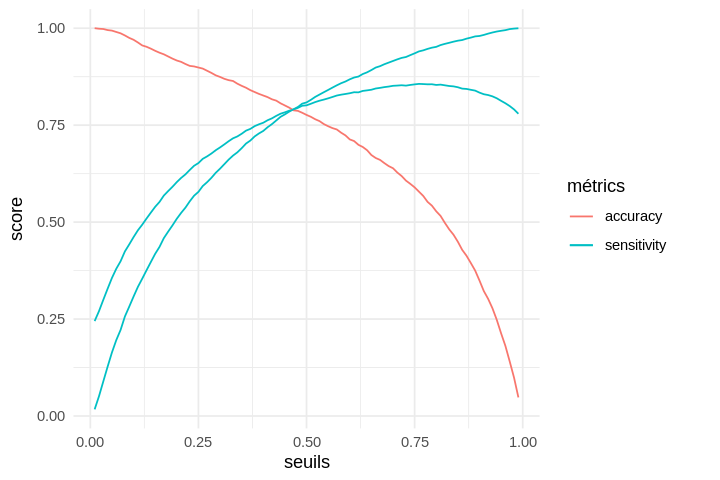

In [103]:
# Métriques de log_model_ros_rus pour divers suils

print_results(log_model_ros_rus)[['plot']]

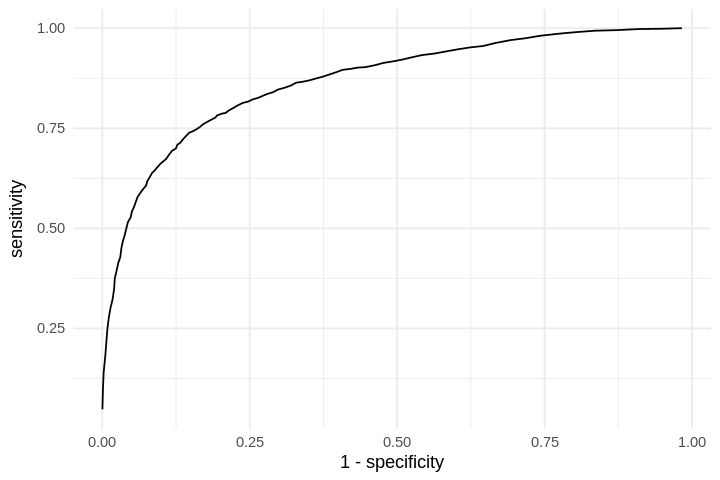

In [104]:
# Courbe ROC de log_model_ros_rus

print_results(log_model_ros_rus)[['roc_curve']]

In [105]:
# AUC de log_model_ros_rus

auc_model(log_model_ros_rus)

Setting levels: control = 0, case = 1

Setting direction: controls < cases



Area under the curve: 0.8686